<a href="https://colab.research.google.com/github/soleildayana/Apophis-Asteroid-Project/blob/main/analisis/nb03_Anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pymcel -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.0 MB/s eta 0:00:00


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import jv
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


## Anomalía excéntrica para Apophis (km / km·s)

Este notebook obtiene el estado de Apophis desde Horizons, convierte a elementos orbitales, genera un reloj de Kepler y resuelve la anomalía excéntrica con tres métodos: punto fijo, Newton-Raphson y serie de Bessel. Se registran iteraciones, tiempos y residuos y se generan gráficos de comparación.

In [3]:
# Constante gravitacional del Sol en km^3/s^2
GM_sun = pc.constantes.mu_sun  # km^3 / s^2

# Parámetros del experimento ampliados para ver no-linealidad
delta = 1e-12  # tolerancia
maxiter = 200
t0_str = '2029-03-20'  # epoch
window_days = 200.0    # Aumentamos de 10 a 200 días
Nsteps = 500           # Suficientes puntos para ver la curva


In [4]:
# 1) Consulta a Horizons para obtener r,v de Apophis (ID 99942) en t0
datos = pc.consulta_horizons(id='99942', location='@0', epochs=t0_str, datos='vectors')

# Extraer vector estado (r,v) de la consulta
def extrae_estado(resultado):
    if isinstance(resultado, tuple) and len(resultado) >= 3:
        estado = np.asarray(resultado[2], dtype=float)
        if estado.ndim == 2:
            estado = estado[0]
        return estado
    return np.asarray(resultado, dtype=float)

estado = extrae_estado(datos)
r0, v0 = estado[:3], estado[3:]

print('r0 (km):', r0)
print('v0 (km/s):', v0)

/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


r0 (km): [-1.58457628e+11 -6.27980414e+09 -3.41511173e+09]
v0 (km/s): [  4153.57204614 -26262.07956129   1501.6412666 ]


In [5]:
# 2) Convertir a elementos orbitales
a, e, inc, Omega, omega, f0 = pc.estado_a_elementos(GM_sun, estado)
print(f'a={a:.6f} km, e={e:.8f}, inclinación ={np.degrees(inc):.4f} deg')
# Convertir f0 a E0
def true_to_eccentric(f, e):
    return 2*np.arctan(np.tan(f/2)/np.sqrt((1+e)/(1-e)))
E0 = true_to_eccentric(f0, e)
M0 = E0 - e*np.sin(E0)
print(f'E0={E0:.12f}, M0={M0:.12f}')

a=132580920136.278259 km, e=0.19185549, inclinación =3.3447 deg
E0=-2.488341915331, M0=-2.371737699148


In [6]:
# 3) Preparar grid temporal y calcular M(t)
half = window_days/2.0
ts_days = np.linspace(-half, half, Nsteps)
ts = ts_days * 86400.0  # segundos relativos
n = np.sqrt(GM_sun / a**3)
Ms = M0 + n * ts
Ms = (Ms + np.pi) % (2*np.pi) - np.pi
print(f'n = {n:.6e} rad/s, pasos = {len(ts)}')

n = 2.386351e-07 rad/s, pasos = 500


In [7]:
# 4) Implementación de solucionadores
def kepler_fixed_point(M, e, tol=1e-12, maxiter=200):
    E = M if abs(e) < 0.8 else np.pi
    for k in range(1, maxiter+1):
        E_next = M + e * np.sin(E)
        if abs(E_next - E) < tol:
            return E_next, k
        E = E_next
    return E, maxiter

def kepler_newton(M, e, tol=1e-12, maxiter=200):
    E = M if abs(e) < 0.8 else np.pi
    for k in range(1, maxiter+1):
        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E = E + dE
        if abs(dE) < tol:
            return E, k
    return E, maxiter

def kepler_bessel(M, e, tol=1e-12, maxiter=200):
    term = 0.0
    s = 1
    while s <= maxiter:
        coeff = (2.0/s) * jv(s, s*e)
        term_s = coeff * np.sin(s*M)
        term += term_s
        if abs(term_s) < tol:
            break
        s += 1
    E = M + term
    return E, s

In [8]:
# 5) Ejecutar experimento
results = {'t_days': list(ts_days)}
for key in ['E_fixed','it_fixed','time_fixed','E_newton','it_newton','time_newton','E_bessel','it_bessel','time_bessel','res_fixed','res_newton','res_bessel']:
    results[key] = []

for M in Ms:
    t0c = time.perf_counter()
    E_f, it_f = kepler_fixed_point(M, e, tol=delta, maxiter=maxiter)
    dt_f = time.perf_counter() - t0c
    res_f = abs(M - (E_f - e*np.sin(E_f)))
    results['E_fixed'].append(E_f); results['it_fixed'].append(it_f); results['time_fixed'].append(dt_f); results['res_fixed'].append(res_f)
    t0c = time.perf_counter()
    E_n, it_n = kepler_newton(M, e, tol=delta, maxiter=maxiter)
    dt_n = time.perf_counter() - t0c
    res_n = abs(M - (E_n - e*np.sin(E_n)))
    results['E_newton'].append(E_n); results['it_newton'].append(it_n); results['time_newton'].append(dt_n); results['res_newton'].append(res_n)
    t0c = time.perf_counter()
    E_b, it_b = kepler_bessel(M, e, tol=delta, maxiter=200)
    dt_b = time.perf_counter() - t0c
    res_b = abs(M - (E_b - e*np.sin(E_b)))
    results['E_bessel'].append(E_b); results['it_bessel'].append(it_b); results['time_bessel'].append(dt_b); results['res_bessel'].append(res_b)

dfres = pd.DataFrame(results)
# calcular r(t) usando E de Newton como referencia
dfres['r_km'] = a * (1 - e * np.cos(dfres['E_newton']))
print('Experimento completado; filas:')
dfres.head()

Experimento completado; filas:


,t_days,E_fixed,it_fixed,time_fixed,E_newton,it_newton,time_newton,E_bessel,it_bessel,time_bessel,res_fixed,res_newton,res_bessel,r_km
0,-100.000000,2.022273,12,0.000088,2.022273,4,0.000021,2.022273,17,0.000277,1.842970e-14,2.220446e-16,2.384759e-13,1.436787e+11
1,-99.599198,2.029894,12,0.000021,2.029894,4,0.000015,2.029894,17,0.000066,2.220446e-14,0.000000e+00,2.158274e-13,1.438528e+11
2,-99.198397,2.037505,12,0.000018,2.037505,4,0.000013,2.037505,17,0.000061,2.664535e-14,0.000000e+00,1.880718e-13,1.440260e+11
3,-98.797595,2.045108,12,0.000017,2.045108,4,0.000012,2.045108,17,0.000060,3.175238e-14,0.000000e+00,1.567635e-13,1.441984e+11
4,-98.396794,2.052701,12,0.000017,2.052701,4,0.000012,2.052701,15,0.000053,3.774758e-14,2.220446e-16,4.336087e-12,1.443699e+11


In [9]:
# 6) Métricas y resumen
summary = pd.DataFrame({
    'time_total': [dfres['time_fixed'].sum(), dfres['time_newton'].sum(), dfres['time_bessel'].sum()],
    'mean_iters': [dfres['it_fixed'].mean(), dfres['it_newton'].mean(), dfres['it_bessel'].mean()],
    'max_iters': [dfres['it_fixed'].max(), dfres['it_newton'].max(), dfres['it_bessel'].max()]
}, index=['Fixed','Newton','Bessel'])


summary.head()

,time_total,mean_iters,max_iters
Fixed,0.009947,13.628,16
Newton,0.006233,3.918,4
Bessel,0.032497,17.052,18


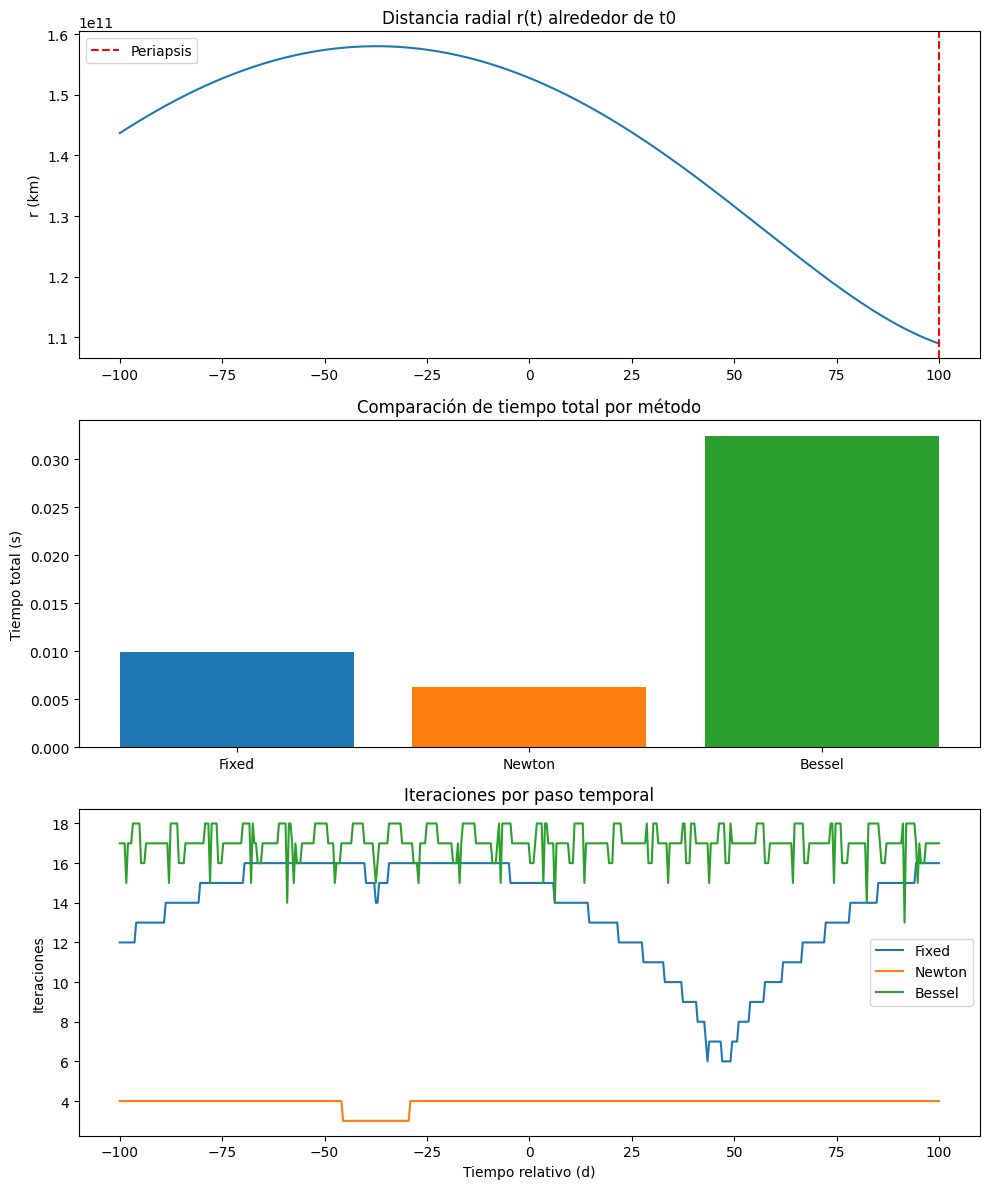

In [10]:
# 7) Visualizaciones
fig, ax = plt.subplots(3,1, figsize=(10,12), sharex=False)
ax[0].plot(ts_days, dfres['r_km'])
ax[0].set_ylabel('r (km)')
ax[0].set_title('Distancia radial r(t) alrededor de t0')
imin = dfres['r_km'].idxmin()
ax[0].axvline(ts_days[imin], color='red', linestyle='--', label='Periapsis')
ax[0].legend()
methods = ['Fixed','Newton','Bessel']
times = [dfres['time_fixed'].sum(), dfres['time_newton'].sum(), dfres['time_bessel'].sum()]
ax[1].bar(methods, times, color=['C0','C1','C2'])
ax[1].set_ylabel('Tiempo total (s)')
ax[1].set_title('Comparación de tiempo total por método')
ax[2].plot(ts_days, dfres['it_fixed'], label='Fixed')
ax[2].plot(ts_days, dfres['it_newton'], label='Newton')
ax[2].plot(ts_days, dfres['it_bessel'], label='Bessel')
ax[2].set_ylabel('Iteraciones')
ax[2].set_xlabel('Tiempo relativo (d)')
ax[2].set_title('Iteraciones por paso temporal')
ax[2].legend()
plt.tight_layout()
plt.show()

### Fase 1 y 2: Anomalía Verdadera y Validación Geométrica

En esta sección:
1. Calculamos $f$ usando la relación de tangentes: $\tan(f/2) = \sqrt{\frac{1+e}{1-e}} \tan(E/2)$.
2. Validamos la distancia radial $r$ comparando $r = a(1 - e \cos E)$ con $r = \frac{p}{1 + e \cos f}$.
3. Visualizamos la evolución de las anomalías.

In [11]:
import numpy as np

# 1) Calcular Anomalía Verdadera (f) usando arctan2 para consistencia de cuadrantes
def eccentric_to_true(E, e):
    return 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                          np.sqrt(1 - e) * np.cos(E / 2))

dfres['f_rad'] = eccentric_to_true(dfres['E_newton'], e)

# 2) Validación geométrica de r
p = a * (1 - e**2) # Parámetro de la cónica
dfres['r_via_f'] = p / (1 + e * np.cos(dfres['f_rad']))

# Calcular residuo entre ambos métodos (debe ser despreciable ~1e-14)
dfres['r_residual'] = np.abs(dfres['r_km'] - dfres['r_via_f'])

print(f"Residuo geométrico máximo en r: {dfres['r_residual'].max():.2e} km")
display(dfres[['t_days', 'E_newton', 'f_rad', 'r_km', 'r_residual']].head())

Residuo geométrico máximo en r: 6.10e-05 km


,t_days,E_newton,f_rad,r_km,r_residual
0,-100.000000,2.022273,2.189073,1.436787e+11,0.000000
1,-99.599198,2.029894,2.195970,1.438528e+11,0.000031
2,-99.198397,2.037505,2.202851,1.440260e+11,0.000031
3,-98.797595,2.045108,2.209715,1.441984e+11,0.000000
4,-98.396794,2.052701,2.216563,1.443699e+11,0.000031


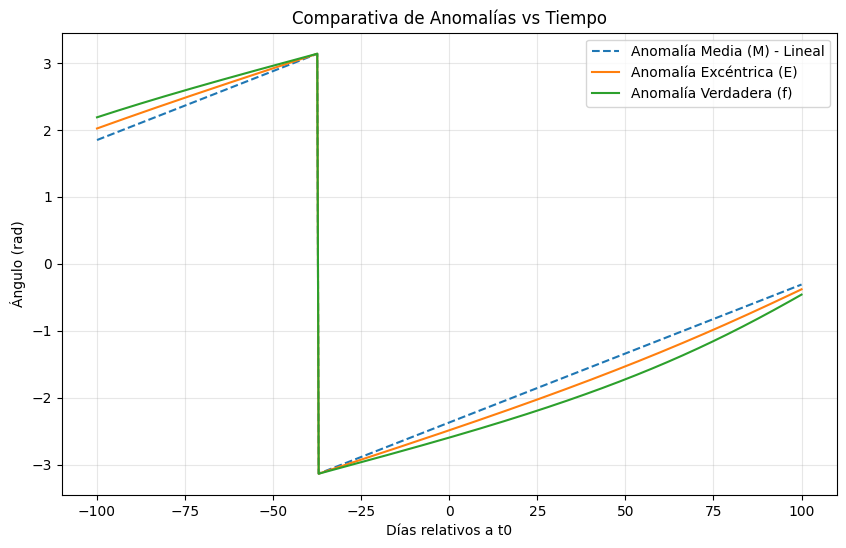

In [12]:
# 3) Visualización de las Anomalías (M, E, f)
plt.figure(figsize=(10, 6))
plt.plot(dfres['t_days'], Ms, label='Anomalía Media (M) - Lineal', linestyle='--')
plt.plot(dfres['t_days'], dfres['E_newton'], label='Anomalía Excéntrica (E)')
plt.plot(dfres['t_days'], dfres['f_rad'], label='Anomalía Verdadera (f)')

plt.title('Comparativa de Anomalías vs Tiempo')
plt.xlabel('Días relativos a t0')
plt.ylabel('Ángulo (rad)')
plt.legend()
plt.grid(True, alpha=0.3)
